# E-MTAB-6701 - Human placenta trophoblast pseudobulk projected into ARCHS4 and GTEx

**Environment:** `clamp-analyses`

Projects human placenta single-cell RNA-seq pseudobulks from `E-MTAB-6701` into two existing CLAMP Hallmark models:

- ARCHS4: `output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/CLAMPfull_hall.rds`
- GTEx: `output/01_model_building/02_gtex/10_CLAMP_hall/CLAMPfull_hall.rds`

The analysis mirrors the macrophage/LPS projection notebook: no new CLAMP model is trained, and inference is run on projected LV scores. The biological question is whether the ARCHS4 model captures trophoblast-specific placental cell-state programs more directly than the GTEx model.

The dataset has donor labels and author/ontology cell-type annotations. We pseudobulk by `donor x cell_type`, project each pseudobulk into both models, and test:

- trophoblast cells vs non-trophoblast placental cells
- extravillous trophoblasts vs other placental cells
- syncytiotrophoblasts / villous cytotrophoblasts vs other placental cells

Primary ARCHS4 target pathways:

```r
C8_DESCARTES_FETAL_PLACENTA_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS
C8_DESCARTES_FETAL_PLACENTA_TROPHOBLAST_GIANT_CELLS
C8_DESCARTES_MAIN_FETAL_EXTRAVILLOUS_TROPHOBLASTS
C8_DESCARTES_MAIN_FETAL_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS
C8_DESCARTES_MAIN_FETAL_TROPHOBLAST_GIANT_CELLS
```

These exact annotations are present in the ARCHS4 model summary and absent as exact pathway names in the GTEx model summary. GTEx is still evaluated fairly for broader stromal, epithelial, fetal/developmental, and placental-like programs.

## Libraries

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(here)
  library(CLAMP)
  library(ggplot2)
  library(ggrepel)
  library(org.Hs.eg.db)
  library(AnnotationDbi)
  library(limma)
  library(Rtsne)
  library(Matrix)
})

## Paths and thresholds

In [2]:
out_dir        <- here("output", "03_model_biology", "00_archs4", "03_tissue_projections", "05_human_placenta_trophoblast_E-MTAB-6701")
data_dir       <- file.path(out_dir, "data")
projection_dir <- file.path(out_dir, "projections")
results_dir    <- file.path(out_dir, "results")
figure_dir     <- file.path(out_dir, "figures")

for (dir_i in c(data_dir, projection_dir, results_dir, figure_dir)) {
  dir.create(dir_i, recursive = TRUE, showWarnings = FALSE)
}

EXPERIMENT_ID <- "E-MTAB-6701"
ATLAS_URL <- "https://ftp.ebi.ac.uk/pub/databases/microarray/data/atlas/sc_experiments/E-MTAB-6701"

LV_FDR_CUTOFF <- 0.05
LV_LOGFC_CUTOFF <- 0.10
PATHWAY_FDR_CUTOFF <- 0.05
PATHWAY_AUC_CUTOFF <- 0.70
MIN_CELLS_PER_PSEUDOBULK <- 20

archs4_trophoblast_pathways <- c(
  "C8_DESCARTES_FETAL_PLACENTA_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS",
  "C8_DESCARTES_FETAL_PLACENTA_TROPHOBLAST_GIANT_CELLS",
  "C8_DESCARTES_MAIN_FETAL_EXTRAVILLOUS_TROPHOBLASTS",
  "C8_DESCARTES_MAIN_FETAL_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS",
  "C8_DESCARTES_MAIN_FETAL_TROPHOBLAST_GIANT_CELLS"
)

broad_gtex_pattern <- paste(
  c("PLACENTA", "TROPHOBLAST", "VILLOUS", "CYTOTROPH", "SYNCYTIO",
    "EXTRAVILLOUS", "STROM", "FIBROBLAST", "EPITHEL", "DEVELOP",
    "EMBRYO", "FETAL", "DECIDUA", "ENDOTHEL", "MESENCHYM"),
  collapse = "|"
)

model_paths <- list(
  ARCHS4 = here("output", "01_model_building", "04_archs4", "06_bp_coverage_rshall", "06_bp_coverage_hall_rs_100", "hall_coverage_rs100_seed_1", "CLAMPfull_hall.rds"),
  GTEx   = here("output", "01_model_building", "02_gtex", "10_CLAMP_hall", "CLAMPfull_hall.rds")
)

list(out_dir = out_dir, models = model_paths)

$out_dir
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/placenta_trophoblast_E-MTAB-6701"

$models
$models$ARCHS4
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/CLAMPfull_hall.rds"

$models$GTEx
[1] "/home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/02_gtex/10_CLAMP_hall/CLAMPfull_hall.rds"

## General helpers

In [3]:
clean_pathway <- function(x) {
  x <- ifelse(is.na(x) | x == "", "unannotated", x)
  x <- gsub("^HALL_HALLMARK_", "", x)
  x <- gsub("^HALLMARK_", "", x)
  x <- gsub("^REACTOME_REACTOME_", "", x)
  x <- gsub("^REACTOME_", "", x)
  x <- gsub("^GOBP_GOBP_|^GOCC_GOCC_|^GOMF_GOMF_", "", x)
  x <- gsub("^GOBP_|^GOCC_|^GOMF_", "", x)
  x <- gsub("^C[0-9]+_", "", x)
  x <- gsub("_", " ", x)
  trimws(gsub("\\s+", " ", x))
}

wrap_label <- function(x, width = 45) {
  vapply(
    x,
    function(s) paste(strwrap(s, width = width), collapse = "\n"),
    character(1),
    USE.NAMES = FALSE
  )
}

empty_plot <- function(label) {
  ggplot() +
    theme_void() +
    annotate("text", x = 0.5, y = 0.5, label = label,
             size = 4, colour = "grey55", hjust = 0.5)
}

cell_type_palette <- c(
  "Extravillous trophoblast" = "#D95F0E",
  "Villous cytotrophoblast" = "#E7298A",
  "Syncytiotrophoblast" = "#A6761D",
  "Hofbauer cell" = "#1B9E77",
  "Fetal fibroblast 1" = "#7570B3",
  "Fetal fibroblast 2" = "#6A3D9A",
  "Fetal endothelial" = "#1F78B4",
  "Maternal endothelial" = "#2C7FB8",
  "Decidual macrophage 1" = "#66A61E",
  "Decidual macrophage 2" = "#7FC97F",
  "Decidual macrophage 3" = "#B2DF8A",
  "Glandular epithelial" = "#E6AB02",
  "Granulocyte" = "#666666",
  "Monocyte" = "#999999",
  "Other" = "grey70"
)

condition_palette <- c(
  "Target" = "#D95F0E",
  "Other" = "#2C7FB8"
)

## Download E-MTAB-6701 files

In [4]:
download_atlas_file <- function(file_name) {
  dest <- file.path(data_dir, file_name)
  if (!file.exists(dest)) {
    download.file(file.path(ATLAS_URL, file_name), dest, mode = "wb", quiet = FALSE)
  } else {
    message("Using cached file: ", basename(dest))
  }
  dest
}

metadata_path <- download_atlas_file("E-MTAB-6701.cell_metadata.tsv")
rows_path     <- download_atlas_file("E-MTAB-6701.aggregated_filtered_counts.mtx_rows.gz")
cols_path     <- download_atlas_file("E-MTAB-6701.aggregated_filtered_counts.mtx_cols.gz")
mtx_path      <- download_atlas_file("E-MTAB-6701.aggregated_filtered_counts.mtx.gz")

file.info(c(metadata_path, rows_path, cols_path, mtx_path))[, c("size", "mtime")]

Using cached file: E-MTAB-6701.cell_metadata.tsv



Using cached file: E-MTAB-6701.aggregated_filtered_counts.mtx_rows.gz



Using cached file: E-MTAB-6701.aggregated_filtered_counts.mtx_cols.gz



Using cached file: E-MTAB-6701.aggregated_filtered_counts.mtx.gz



,size,mtime
,<dbl>,<dttm>
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/placenta_trophoblast_E-MTAB-6701/data/E-MTAB-6701.cell_metadata.tsv,45437700,2026-05-02 09:23:16
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/placenta_trophoblast_E-MTAB-6701/data/E-MTAB-6701.aggregated_filtered_counts.mtx_rows.gz,134570,2026-05-02 09:23:17
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/placenta_trophoblast_E-MTAB-6701/data/E-MTAB-6701.aggregated_filtered_counts.mtx_cols.gz,459556,2026-05-02 09:23:18
/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/03_tissue_projections/00_gtex_archs4_projection/tissue_projections/placenta_trophoblast_E-MTAB-6701/data/E-MTAB-6701.aggregated_filtered_counts.mtx.gz,829777033,2026-05-02 09:24:13


## Map cell types in R

Read the EBI cell metadata and map raw author labels to canonical cell-type names using `dplyr::case_when`. Placenta filtering, donor assignment, and sample-name sanitisation all happen here in R.

In [ ]:
cell_types_path <- file.path(data_dir, "E-MTAB-6701_placenta_cell_types.csv")

if (!file.exists(cell_types_path)) {
  meta_raw <- data.table::fread(metadata_path, sep = "\t",
    select = c("id", "individual", "organism_part",
               "inferred_cell_type_-_authors_labels"))

  meta_raw <- meta_raw %>%
    dplyr::filter(tolower(organism_part) == "placenta") %>%
    dplyr::rename(donor = individual,
                  author_label = `inferred_cell_type_-_authors_labels`) %>%
    dplyr::mutate(
      label_lc = tolower(author_label),
      cell_type = dplyr::case_when(
        grepl("extravillous trophoblast|\\(evt\\)", label_lc)                     ~ "Extravillous trophoblast",
        grepl("syncytiotrophoblast|\\(sct\\)", label_lc)                          ~ "Syncytiotrophoblast",
        grepl("villous cytotrophoblast|\\(vct\\)", label_lc)                      ~ "Villous cytotrophoblast",
        grepl("hofbauer", label_lc)                                                   ~ "Hofbauer cell",
        grepl("fetal fibroblast", label_lc) & grepl("ffb2", label_lc)                ~ "Fetal fibroblast 2",
        grepl("fetal fibroblast", label_lc)                                           ~ "Fetal fibroblast 1",
        grepl("fetal endothelial", label_lc)                                          ~ "Fetal endothelial",
        grepl("maternal endothelial", label_lc)                                       ~ "Maternal endothelial",
        grepl("decidual macrophage", label_lc) & grepl("dm1", label_lc)              ~ "Decidual macrophage 1",
        grepl("decidual macrophage", label_lc) & grepl("dm2", label_lc)              ~ "Decidual macrophage 2",
        grepl("decidual macrophage", label_lc) & grepl("dm3", label_lc)              ~ "Decidual macrophage 3",
        grepl("glandular epithelial", label_lc)                                       ~ "Glandular epithelial",
        grepl("granulocyte", label_lc)                                                ~ "Granulocyte",
        grepl("monocyte", label_lc)                                                   ~ "Monocyte",
        TRUE                                                                           ~ "Other"
      ),
      sample = paste0(donor, "__", gsub("[^A-Za-z0-9]+", "_", cell_type))
    ) %>%
    dplyr::select(id, donor, cell_type, sample)

  data.table::fwrite(meta_raw, cell_types_path)
  cat("Cell type mapping saved:", nrow(meta_raw), "placenta cells\n")
} else {
  meta_raw <- data.table::fread(cell_types_path) %>% as.data.frame()
  cat("Using cached cell type mapping:", nrow(meta_raw), "placenta cells\n")
}

meta_raw %>% dplyr::count(cell_type, name = "n_cells") %>%
  dplyr::arrange(dplyr::desc(n_cells))

## Pseudobulk aggregation in R

Read the sparse count matrix with `Matrix::readMM`, filter to placenta cells, then aggregate into donor × cell_type pseudobulks using sparse matrix multiplication. All logic is pure R: no Python.

In [5]:
pseudobulk_counts_path <- file.path(data_dir, "E-MTAB-6701_placenta_pseudobulk_counts.rds")
pseudobulk_meta_path   <- file.path(data_dir, "E-MTAB-6701_placenta_pseudobulk_metadata.csv")

if (!file.exists(pseudobulk_counts_path) || !file.exists(pseudobulk_meta_path)) {
  genes_vec <- data.table::fread(rows_path, header = FALSE, sep = "\t")[[1]]
  cols_vec  <- data.table::fread(cols_path, header = FALSE, sep = "\t")[[1]]

  cat("Reading sparse count matrix...\n")
  mat <- Matrix::readMM(gzcon(file(mtx_path, open = "rb")))
  rownames(mat) <- genes_vec
  colnames(mat) <- cols_vec

  keep_ids <- intersect(colnames(mat), meta_raw$id)
  mat      <- mat[, keep_ids, drop = FALSE]
  cat("Placenta cells retained in matrix:", ncol(mat), "\n")

  id_map <- meta_raw[meta_raw$id %in% keep_ids, ]

  group_counts <- id_map %>%
    dplyr::count(sample, donor, cell_type, name = "n_cells") %>%
    dplyr::filter(n_cells >= MIN_CELLS_PER_PSEUDOBULK) %>%
    dplyr::arrange(donor, cell_type)

  valid_ids <- id_map$id[id_map$sample %in% group_counts$sample]
  mat       <- mat[, valid_ids, drop = FALSE]

  sample_fac <- factor(
    id_map$sample[match(valid_ids, id_map$id)],
    levels = group_counts$sample
  )

  ind <- Matrix::sparseMatrix(
    i    = seq_along(valid_ids),
    j    = as.integer(sample_fac),
    x    = 1,
    dims = c(length(valid_ids), nrow(group_counts))
  )

  counts_pb <- as.matrix(mat %*% ind)
  colnames(counts_pb) <- group_counts$sample

  saveRDS(counts_pb, pseudobulk_counts_path)

  meta_pb <- group_counts %>%
    dplyr::mutate(
      condition_trophoblast = ifelse(
        grepl("trophoblast|cytotrophoblast", cell_type, ignore.case = TRUE),
        "Trophoblast", "Other"),
      condition_evt = ifelse(cell_type == "Extravillous trophoblast", "EVT", "Other"),
      condition_sct_vct = ifelse(
        cell_type %in% c("Syncytiotrophoblast", "Villous cytotrophoblast"),
        "SCT_VCT", "Other")
    )
  data.table::fwrite(meta_pb, pseudobulk_meta_path)
  cat("Wrote", nrow(counts_pb), "genes x", ncol(counts_pb), "pseudobulks\n")
} else {
  counts_pb <- readRDS(pseudobulk_counts_path)
  meta_pb   <- data.table::fread(pseudobulk_meta_path) %>% as.data.frame()
}

cat("Placenta cells retained:", nrow(meta_raw), "\n")
cat("Pseudobulk samples:", nrow(meta_pb), "\n")
print(table(meta_pb$donor, meta_pb$condition_trophoblast))
meta_pb %>% dplyr::count(cell_type, condition_trophoblast, name = "n_pseudobulk") %>%
  dplyr::arrange(condition_trophoblast, cell_type)

Using cached pseudobulk outputs



Placenta cells retained: 41755 


Pseudobulk samples: 46 


     
      Other Trophoblast
  D10     7           3
  D11     4           3
  D12     9           3
  D8      5           3
  D9      6           3


cell_type,condition_trophoblast,n_pseudobulk
<chr>,<chr>,<int>
Decidual macrophage 2,Other,4
Decidual macrophage 3,Other,5
Fetal endothelial,Other,2
Fetal fibroblast 1,Other,5
Fetal fibroblast 2,Other,2
Glandular epithelial,Other,1
Granulocyte,Other,1
Hofbauer cell,Other,5
Maternal endothelial,Other,1


## Convert Ensembl IDs to HGNC symbols and normalize

In [6]:
counts_sym_path <- file.path(data_dir, "E-MTAB-6701_placenta_pseudobulk_counts_hgnc.rds")
norm_path       <- file.path(data_dir, "E-MTAB-6701_placenta_pseudobulk_norm_clamp.rds")

if (!file.exists(norm_path)) {
  counts_ens <- counts_pb
  rownames(counts_ens) <- sub("\\..*", "", rownames(counts_ens))

  hgnc_ids <- AnnotationDbi::mapIds(
    org.Hs.eg.db,
    keys     = unique(rownames(counts_ens)),
    column   = "SYMBOL",
    keytype  = "ENSEMBL",
    multiVals = "first"
  )
  hgnc_vec <- unname(hgnc_ids[rownames(counts_ens)])

  keep <- !is.na(hgnc_vec) & hgnc_vec != ""
  counts_pb <- counts_ens[keep, , drop = FALSE]
  rownames(counts_pb) <- hgnc_vec[keep]
  counts_pb <- rowsum(counts_pb, rownames(counts_pb), reorder = FALSE)

  cpm_pb  <- cpmCLAMP(counts_pb)
  prep_pb <- preprocessCLAMP(Y = cpm_pb, mean_cutoff = 0.5, var_cutoff = 0.1)
  norm_pb <- zscoreCLAMP(Y_filtered = prep_pb$Y_filtered,
                         rowStats = prep_pb$rowStats)

  saveRDS(counts_pb, counts_sym_path)
  saveRDS(norm_pb, norm_path)
} else {
  counts_pb <- readRDS(counts_sym_path)
  norm_pb   <- readRDS(norm_path)
}

cat("HGNC pseudobulk count matrix:", nrow(counts_pb), "genes x", ncol(counts_pb), "samples\n")
cat("Normalized matrix:", nrow(norm_pb), "genes x", ncol(norm_pb), "samples\n")

HGNC pseudobulk count matrix: 20470 genes x 46 samples


Normalized matrix: 14846 genes x 46 samples


## Load projection models

In [7]:
read_projection_model <- function(path) {
  mdl <- readRDS(path)
  keep <- list(
    Z = as.matrix(mdl$Z),
    L2 = mdl$L2,
    summary = mdl$summary
  )
  rm(mdl)
  gc()
  keep
}

models <- lapply(model_paths, read_projection_model)

for (model_name in names(models)) {
  mdl <- models[[model_name]]
  n_sig <- sum(mdl$summary$FDR < PATHWAY_FDR_CUTOFF &
                 mdl$summary$AUC > PATHWAY_AUC_CUTOFF,
               na.rm = TRUE)
  cat(model_name, "model - genes:", nrow(mdl$Z),
      "| LVs:", ncol(mdl$Z),
      "| significant pathway annotations:", n_sig, "
")
}

archs4_exact_target_check <- as.data.frame(models$ARCHS4$summary) %>%
  dplyr::mutate(AUC = as.numeric(AUC), FDR = as.numeric(FDR)) %>%
  dplyr::filter(pathway %in% archs4_trophoblast_pathways) %>%
  dplyr::arrange(pathway, dplyr::desc(AUC), FDR)

gtex_exact_target_check <- as.data.frame(models$GTEx$summary) %>%
  dplyr::mutate(AUC = as.numeric(AUC), FDR = as.numeric(FDR)) %>%
  dplyr::filter(pathway %in% archs4_trophoblast_pathways) %>%
  dplyr::arrange(pathway, dplyr::desc(AUC), FDR)

cat("ARCHS4 exact target annotations:", nrow(archs4_exact_target_check), "
")
cat("GTEx exact target annotations:", nrow(gtex_exact_target_check), "
")
archs4_exact_target_check %>% dplyr::select(LV, pathway, AUC, FDR)

ARCHS4 model - genes: 18423 | LVs: 1728 | significant pathway annotations: 1794 
GTEx model - genes: 21613 | LVs: 578 | significant pathway annotations: 886 


ARCHS4 exact target annotations: 14 


GTEx exact target annotations: 0 


,LV,pathway,AUC,FDR
,<chr>,<chr>,<dbl>,<dbl>
C82342,LV658,C8_DESCARTES_FETAL_PLACENTA_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS,0.9242311,2.241244e-06
C8234,LV46,C8_DESCARTES_FETAL_PLACENTA_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS,0.8874958,5.019596e-05
C82341,LV442,C8_DESCARTES_FETAL_PLACENTA_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS,0.7120039,4.712080e-02
C8235,LV46,C8_DESCARTES_FETAL_PLACENTA_TROPHOBLAST_GIANT_CELLS,0.9982730,2.094239e-06
C82351,LV79,C8_DESCARTES_FETAL_PLACENTA_TROPHOBLAST_GIANT_CELLS,0.6840885,1.184711e-01
C82352,LV1223,C8_DESCARTES_FETAL_PLACENTA_TROPHOBLAST_GIANT_CELLS,0.5762700,4.858577e-01
C82353,LV1267,C8_DESCARTES_FETAL_PLACENTA_TROPHOBLAST_GIANT_CELLS,0.5746702,4.980415e-01
C82902,LV460,C8_DESCARTES_MAIN_FETAL_EXTRAVILLOUS_TROPHOBLASTS,0.8435260,1.155100e-06
C8290,LV46,C8_DESCARTES_MAIN_FETAL_EXTRAVILLOUS_TROPHOBLASTS,0.8133890,8.929868e-06


## Projection and contrast helpers

In [8]:
build_lv_annot <- function(mdl,
                           pathway_fdr_cutoff = PATHWAY_FDR_CUTOFF,
                           auc_cutoff = PATHWAY_AUC_CUTOFF) {
  mdl$summary %>%
    dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::group_by(LV) %>%
    dplyr::arrange(dplyr::desc(AUC), FDR, .by_group = TRUE) %>%
    dplyr::summarise(
      pathways = paste(clean_pathway(pathway), collapse = " | "),
      top_AUC  = max(AUC, na.rm = TRUE),
      n_paths  = dplyr::n(),
      .groups  = "drop"
    )
}

project_model <- function(mdl, norm_mat, model_name) {
  common <- intersect(rownames(mdl$Z), rownames(norm_mat))
  mdl_sub <- list(
    Z = mdl$Z[common, , drop = FALSE],
    L2 = mdl$L2
  )
  B <- projectCLAMP(CLAMPres = mdl_sub,
                    newdata = norm_mat[common, , drop = FALSE])
  cat(model_name, "common genes:", length(common),
      sprintf("(%.1f%% of model genes)
", 100 * length(common) / nrow(mdl$Z)))
  B
}

rank_lvs_contrast <- function(B, meta, mdl, model_name, contrast_name, condition_col, target_label) {
  meta_aligned <- meta[match(colnames(B), meta$sample), , drop = FALSE]
  stopifnot(!any(is.na(meta_aligned$sample)))
  stopifnot(all(meta_aligned$sample == colnames(B)))

  meta_aligned$condition <- relevel(
    factor(meta_aligned[[condition_col]], levels = c("Other", target_label)),
    ref = "Other"
  )
  donor <- factor(meta_aligned$donor)
  design <- model.matrix(~ donor + condition, data = meta_aligned)
  colnames(design) <- make.names(colnames(design))

  coef_name <- paste0("condition", make.names(target_label))
  stopifnot(coef_name %in% colnames(design))

  fit <- lmFit(B, design)
  fit <- eBayes(fit)
  de <- topTable(fit, coef = coef_name, n = Inf,
                 adjust.method = "BH", sort.by = "P")
  de$LV <- rownames(de)

  annot <- build_lv_annot(mdl)
  de %>%
    dplyr::left_join(annot, by = "LV") %>%
    dplyr::mutate(
      model = model_name,
      contrast = contrast_name,
      target_label = target_label,
      pathways = ifelse(is.na(pathways), "unannotated", pathways),
      top_AUC = ifelse(is.na(top_AUC), 0, top_AUC),
      n_paths = ifelse(is.na(n_paths), 0L, as.integer(n_paths)),
      abs_logFC = abs(logFC),
      direction = dplyr::case_when(
        logFC > 0 ~ paste0("Higher in ", target_label),
        logFC < 0 ~ "Higher in Other",
        TRUE ~ "No shift"
      )
    ) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(abs_logFC))
}

extract_shifted_pathways <- function(lv_ranked, mdl, model_name,
                                     lv_fdr_cutoff = LV_FDR_CUTOFF,
                                     lfc_cutoff = LV_LOGFC_CUTOFF,
                                     pathway_fdr_cutoff = PATHWAY_FDR_CUTOFF,
                                     auc_cutoff = PATHWAY_AUC_CUTOFF) {
  annot <- mdl$summary %>%
    dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    dplyr::filter(FDR < pathway_fdr_cutoff, AUC > auc_cutoff) %>%
    dplyr::mutate(pathway_clean = clean_pathway(pathway))

  lv_ranked %>%
    dplyr::filter(adj.P.Val < lv_fdr_cutoff, abs_logFC >= lfc_cutoff) %>%
    dplyr::inner_join(annot, by = "LV") %>%
    dplyr::mutate(model = model_name) %>%
    dplyr::arrange(contrast, adj.P.Val, dplyr::desc(abs_logFC), dplyr::desc(AUC))
}

## Plot helpers

In [9]:
make_tsne_plot <- function(B, meta, title = NULL, perplexity = 15, seed = 42) {
  set.seed(seed)
  n_samples <- ncol(B)
  perp <- min(perplexity, floor((n_samples - 1) / 3))
  if (perp < 1) return(empty_plot("Too few samples for t-SNE"))

  tsne_out <- Rtsne::Rtsne(t(B), perplexity = perp,
                            check_duplicates = FALSE, verbose = FALSE)
  df <- as.data.frame(tsne_out$Y)
  colnames(df) <- c("tSNE1", "tSNE2")
  df$sample <- colnames(B)
  df <- df %>% dplyr::left_join(meta, by = "sample")

  n_donors <- length(unique(df$donor))
  donor_shapes <- setNames(
    (15:19)[seq_len(min(n_donors, 5))],
    sort(unique(df$donor))[seq_len(min(n_donors, 5))]
  )

  ggplot(df, aes(tSNE1, tSNE2, color = cell_type, shape = donor, label = sample)) +
    geom_point(size = 3.2, alpha = 0.9) +
    ggrepel::geom_text_repel(size = 2.4, colour = "black",
                             show.legend = FALSE, max.overlaps = 35) +
    scale_color_manual(values = cell_type_palette, na.value = "grey70") +
    scale_shape_manual(values = donor_shapes) +
    labs(title = title,
         x = "t-SNE 1", y = "t-SNE 2",
         color = "Cell type", shape = "Donor") +
    theme_bw(base_size = 12)
}

make_volcano <- function(lv_ranked,
                         fdr_cutoff = LV_FDR_CUTOFF,
                         lfc_cutoff = LV_LOGFC_CUTOFF,
                         label_top = 15,
                         title = NULL) {
  target_label <- unique(lv_ranked$target_label)[1]
  higher_target <- paste0("Higher in ", target_label)
  df <- lv_ranked %>%
    dplyr::mutate(
      sig = dplyr::case_when(
        adj.P.Val < fdr_cutoff & abs_logFC >= lfc_cutoff & logFC > 0 ~ higher_target,
        adj.P.Val < fdr_cutoff & abs_logFC >= lfc_cutoff & logFC < 0 ~ "Higher in Other",
        TRUE ~ "not selected"
      ),
      neg_log10_fdr = pmin(-log10(pmax(adj.P.Val, .Machine$double.xmin)), 60)
    )

  top_ids <- df %>%
    dplyr::filter(sig != "not selected") %>%
    dplyr::arrange(dplyr::desc(abs_logFC), adj.P.Val) %>%
    dplyr::slice_head(n = label_top) %>%
    dplyr::pull(LV)

  df$label <- ifelse(df$LV %in% top_ids, df$LV, NA_character_)

  ggplot(df, aes(logFC, neg_log10_fdr, color = sig)) +
    geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", color = "grey50") +
    geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dotted", color = "grey40") +
    geom_point(alpha = 0.75, size = 1.8) +
    ggrepel::geom_text_repel(aes(label = label), size = 2.8, colour = "black",
                             max.overlaps = 25, na.rm = TRUE,
                             show.legend = FALSE) +
    scale_color_manual(values = c(
      setNames("#D95F0E", higher_target),
      "Higher in Other" = "#2C7FB8",
      "not selected" = "grey75"
    )) +
    labs(title = title,
         x = paste0("log2 fold-change (", target_label, " vs other)"),
         y = "-log10(FDR)",
         color = NULL) +
    theme_bw(base_size = 12)
}

make_lv_score_plot <- function(B, meta, lv, model_name, lv_label = NULL, title = NULL) {
  if (is.na(lv) || !lv %in% rownames(B)) {
    return(empty_plot(paste(model_name, "no matching LV to plot")))
  }

  df <- data.frame(
    sample = colnames(B),
    score = as.numeric(B[lv, ]),
    stringsAsFactors = FALSE
  ) %>%
    dplyr::left_join(meta, by = "sample")

  cell_order <- df %>%
    dplyr::group_by(cell_type) %>%
    dplyr::summarise(median_score = median(score, na.rm = TRUE), .groups = "drop") %>%
    dplyr::arrange(dplyr::desc(median_score)) %>%
    dplyr::pull(cell_type)

  df$cell_type <- factor(df$cell_type, levels = cell_order)
  if (is.null(title)) title <- paste0(model_name, " ", lv)
  if (is.null(lv_label)) lv_label <- lv

  ggplot(df, aes(cell_type, score)) +
    geom_boxplot(aes(fill = condition_trophoblast), outlier.shape = NA,
                 alpha = 0.25, colour = "grey35", width = 0.65) +
    geom_point(aes(color = condition_trophoblast, shape = donor),
               position = position_jitter(width = 0.12, height = 0),
               size = 2.3, alpha = 0.9) +
    scale_fill_manual(values = c(Trophoblast = "#D95F0E", Other = "#2C7FB8"), name = NULL) +
    scale_color_manual(values = c(Trophoblast = "#D95F0E", Other = "#2C7FB8"), name = NULL) +
    labs(title = title,
         subtitle = lv_label,
         x = NULL,
         y = "Projected LV score",
         shape = "Donor") +
    coord_flip() +
    theme_bw(base_size = 11) +
    theme(
      plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
      plot.subtitle = element_text(size = 9, hjust = 0.5),
      axis.text.y = element_text(size = 9)
    )
}

## Project E-MTAB-6701 pseudobulks into ARCHS4 and GTEx

In [10]:
B_list <- lapply(names(models), function(model_name) {
  project_model(models[[model_name]], norm_pb, model_name)
})
names(B_list) <- names(models)

for (model_name in names(B_list)) {
  B <- B_list[[model_name]]
  write.csv(as.data.frame(B),
            file.path(projection_dir, paste0("E-MTAB-6701_placenta_", model_name, "_projection.csv")),
            row.names = TRUE)
  cat(model_name, "projection:", nrow(B), "LVs x", ncol(B), "samples
")
}

ARCHS4 common genes: 13813 (75.0% of model genes)
GTEx common genes: 13374 (61.9% of model genes)


ARCHS4 projection: 1728 LVs x 46 samples
GTEx projection: 578 LVs x 46 samples


## t-SNE of projected LV scores

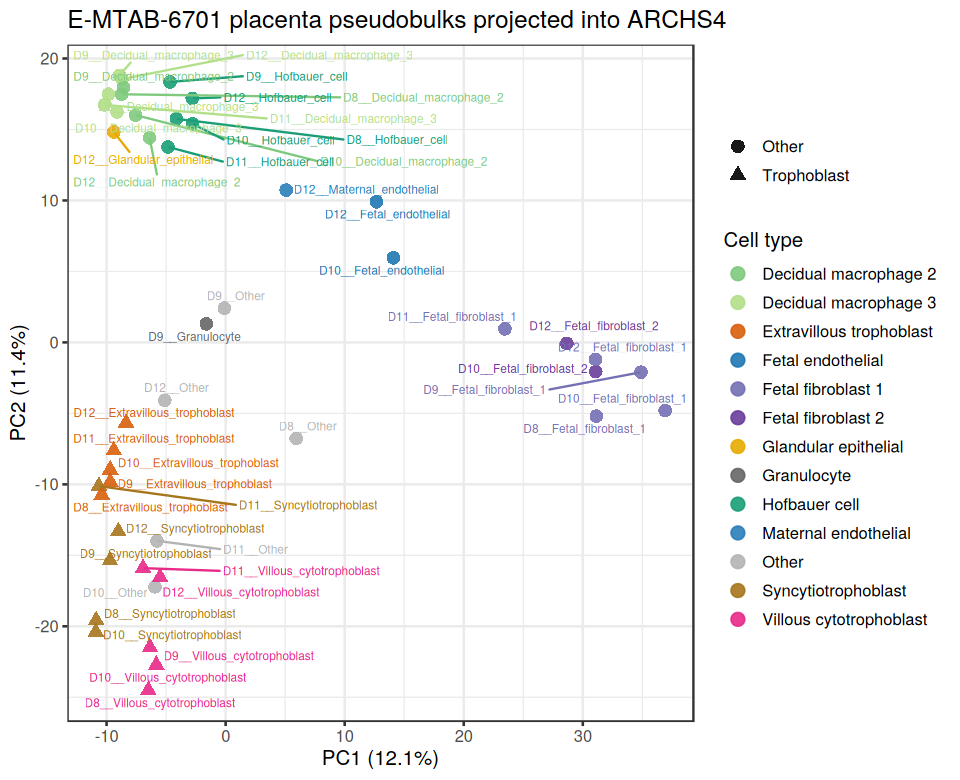

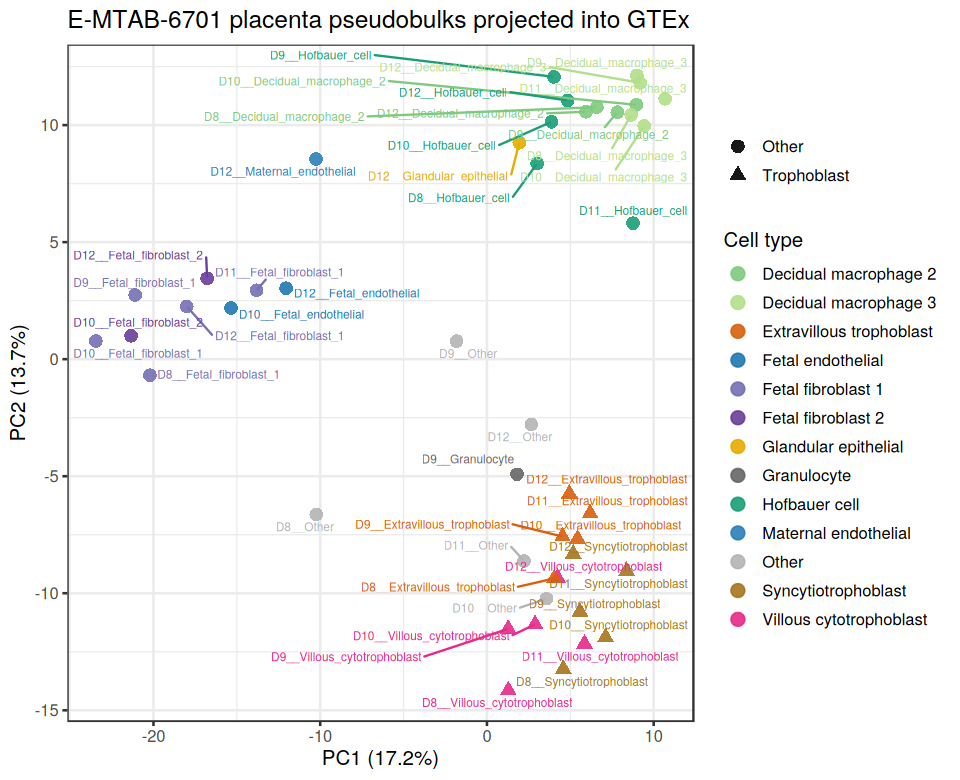

In [11]:
options(repr.plot.width = 8, repr.plot.height = 6.5)

for (model_name in names(B_list)) {
  p <- make_tsne_plot(B_list[[model_name]], meta_pb,
                      title = paste0("E-MTAB-6701 placenta pseudobulks projected into ", model_name))
  print(p)
  ggsave(file.path(figure_dir, paste0("tsne_", model_name, ".png")),
         plot = p, width = 8, height = 6.5, dpi = 150)
}

## K-means ARI: annotated cell types vs projected LV scores

Run k-means (k = number of distinct annotated cell types) on standardised projected LV scores from each model across an ensemble of 50 random seeds. Compute ARI between k-means clusters and annotated cell-type labels for each seed. Higher mean ARI indicates the projection geometry better recovers known cell identities.

label_name,model,n_samples,n_labels,centers,n_projected_LVs,ARI,ari_rank
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<dbl>,<int>
Annotated cell type,GTEx,46,13,13,578,0.86295929,1
Annotated cell type,ARCHS4,46,13,13,1728,0.82589962,2
EVT vs other,GTEx,46,2,2,578,-0.09717314,1
EVT vs other,ARCHS4,46,2,2,1728,-0.10313480,2
SCT/VCT vs other,GTEx,46,2,2,578,-0.10022779,1
SCT/VCT vs other,ARCHS4,46,2,2,1728,-0.11264842,2
Trophoblast vs other,GTEx,46,2,2,578,-0.03162737,1
Trophoblast vs other,ARCHS4,46,2,2,1728,-0.07165549,2


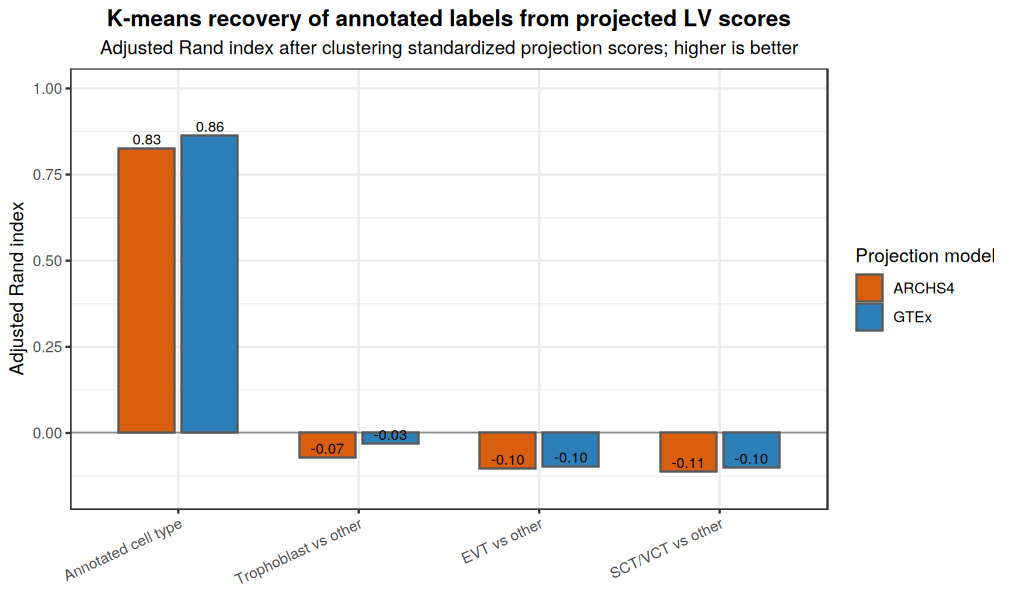

In [12]:
N_SEEDS   <- 50
BASE_SEED <- 6701

adjusted_rand_index <- function(labels_true, labels_pred) {
  keep        <- !is.na(labels_true) & !is.na(labels_pred)
  labels_true <- droplevels(as.factor(labels_true[keep]))
  labels_pred <- droplevels(as.factor(labels_pred[keep]))
  n           <- length(labels_true)
  if (n < 2) return(NA_real_)

  tab   <- table(labels_true, labels_pred)
  ch2   <- function(x) x * (x - 1) / 2
  total <- ch2(n)
  if (total == 0) return(NA_real_)

  idx     <- sum(ch2(tab))
  row_idx <- sum(ch2(rowSums(tab)))
  col_idx <- sum(ch2(colSums(tab)))
  exp_idx <- row_idx * col_idx / total
  max_idx <- 0.5 * (row_idx + col_idx)
  denom   <- max_idx - exp_idx

  if (isTRUE(all.equal(denom, 0)))
    return(ifelse(isTRUE(all.equal(idx, max_idx)), 1, 0))
  (idx - exp_idx) / denom
}

prepare_for_kmeans <- function(B) {
  X    <- t(B)
  keep <- apply(X, 2, function(x) all(is.finite(x)) && stats::sd(x) > 0)
  X    <- scale(X[, keep, drop = FALSE])
  X[, apply(X, 2, function(x) all(is.finite(x))), drop = FALSE]
}

run_ari_ensemble <- function(B, meta, n_seeds = N_SEEDS) {
  X       <- prepare_for_kmeans(B)
  samples <- intersect(rownames(X), meta$sample[!is.na(meta$cell_type)])
  X       <- X[samples, , drop = FALSE]
  labels  <- meta$cell_type[match(samples, meta$sample)]

  k       <- length(unique(labels))
  centers <- min(k, nrow(unique(as.data.frame(round(X, 8)))), nrow(X) - 1)
  if (centers < 2 || nrow(X) < 3)
    return(data.frame(seed = integer(), ari = numeric()))

  dplyr::bind_rows(lapply(seq_len(n_seeds), function(s) {
    set.seed(BASE_SEED + s)
    km <- stats::kmeans(X, centers = centers, nstart = 25, iter.max = 200)
    data.frame(seed = BASE_SEED + s,
               ari  = adjusted_rand_index(labels, km$cluster))
  }))
}

ari_ensemble <- dplyr::bind_rows(lapply(names(B_list), function(model_name) {
  df       <- run_ari_ensemble(B_list[[model_name]], meta_pb)
  df$model <- model_name
  df
}))

ari_summary <- ari_ensemble %>%
  dplyr::group_by(model) %>%
  dplyr::summarise(mean_ari = mean(ari, na.rm = TRUE),
                   sd_ari   = sd(ari,   na.rm = TRUE),
                   .groups  = "drop") %>%
  dplyr::arrange(dplyr::desc(mean_ari))

write.csv(ari_summary,
          file.path(results_dir, "kmeans_ari_celltype_ARCHS4_vs_GTEx.csv"),
          row.names = FALSE)
write.csv(ari_ensemble,
          file.path(results_dir, "kmeans_ari_ensemble_ARCHS4_vs_GTEx.csv"),
          row.names = FALSE)

p_ari <- ggplot(ari_ensemble, aes(model, ari, fill = model)) +
  geom_violin(alpha = 0.55, colour = "grey40", width = 0.7) +
  geom_jitter(width = 0.08, size = 1.8, alpha = 0.7, colour = "grey20") +
  geom_crossbar(
    data = ari_summary,
    aes(y = mean_ari, ymin = mean_ari, ymax = mean_ari),
    width = 0.4, colour = "black", linewidth = 0.8, fatten = 0
  ) +
  geom_hline(yintercept = 0, colour = "grey55", linewidth = 0.35) +
  scale_fill_manual(values = c(ARCHS4 = "#D95F0E", GTEx = "#2C7FB8")) +
  labs(
    title    = "K-means recovery of annotated cell types from projected LV scores",
    subtitle = paste0("ARI across ", N_SEEDS, " seeds (k = ", length(unique(meta_pb$cell_type)),
                      " cell types); black bar = mean"),
    x = NULL, y = "Adjusted Rand index", fill = "Model"
  ) +
  theme_bw(base_size = 11) +
  theme(plot.title    = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5),
        legend.position = "none")

options(repr.plot.width = 5, repr.plot.height = 5)
print(p_ari)
ggsave(file.path(figure_dir, "kmeans_ari_celltype_ARCHS4_vs_GTEx.png"),
       plot = p_ari, width = 5, height = 5, dpi = 150)

ari_summary

## Projected LV contrasts

In [13]:
contrast_definitions <- data.frame(
  contrast = c("trophoblast_vs_other", "evt_vs_other", "sct_vct_vs_other"),
  condition_col = c("condition_trophoblast", "condition_evt", "condition_sct_vct"),
  target_label = c("Trophoblast", "EVT", "SCT_VCT"),
  stringsAsFactors = FALSE
)

ranked_lvs <- list()

for (contrast_i in seq_len(nrow(contrast_definitions))) {
  contrast_name <- contrast_definitions$contrast[contrast_i]
  condition_col <- contrast_definitions$condition_col[contrast_i]
  target_label <- contrast_definitions$target_label[contrast_i]

  ranked_lvs[[contrast_name]] <- lapply(names(models), function(model_name) {
    rank_lvs_contrast(B = B_list[[model_name]],
                      meta = meta_pb,
                      mdl = models[[model_name]],
                      model_name = model_name,
                      contrast_name = contrast_name,
                      condition_col = condition_col,
                      target_label = target_label)
  })
  names(ranked_lvs[[contrast_name]]) <- names(models)

  for (model_name in names(ranked_lvs[[contrast_name]])) {
    ranked_tbl <- ranked_lvs[[contrast_name]][[model_name]]
    write.csv(ranked_tbl,
              file.path(results_dir, paste0(model_name, "_", contrast_name, "_projected_LVs.csv")),
              row.names = FALSE)

    n_up <- sum(ranked_tbl$adj.P.Val < LV_FDR_CUTOFF &
                  ranked_tbl$abs_logFC >= LV_LOGFC_CUTOFF & ranked_tbl$logFC > 0)
    n_dn <- sum(ranked_tbl$adj.P.Val < LV_FDR_CUTOFF &
                  ranked_tbl$abs_logFC >= LV_LOGFC_CUTOFF & ranked_tbl$logFC < 0)
    cat(model_name, contrast_name, "selected LVs:",
        "higher in target =", n_up,
        "| higher in other =", n_dn, "
")
  }
}

combined_ranked_lvs <- dplyr::bind_rows(lapply(ranked_lvs, dplyr::bind_rows)) %>%
  dplyr::arrange(contrast, model, adj.P.Val, dplyr::desc(abs_logFC))

selected_lvs <- combined_ranked_lvs %>%
  dplyr::filter(adj.P.Val < LV_FDR_CUTOFF, abs_logFC >= LV_LOGFC_CUTOFF) %>%
  dplyr::arrange(contrast, model, adj.P.Val, dplyr::desc(abs_logFC))

write.csv(combined_ranked_lvs,
          file.path(results_dir, "all_projected_LV_contrasts_ARCHS4_and_GTEx.csv"),
          row.names = FALSE)
write.csv(selected_lvs,
          file.path(results_dir, "selected_projected_LV_contrasts_ARCHS4_and_GTEx.csv"),
          row.names = FALSE)

selected_lvs %>%
  dplyr::select(contrast, model, LV, logFC, adj.P.Val, direction, top_AUC, n_paths, pathways) %>%
  dplyr::group_by(contrast, model) %>%
  dplyr::slice_head(n = 10)

ARCHS4 trophoblast_vs_other selected LVs: higher in target = 6 | higher in other = 3 
GTEx trophoblast_vs_other selected LVs: higher in target = 20 | higher in other = 24 
ARCHS4 evt_vs_other selected LVs: higher in target = 3 | higher in other = 4 
GTEx evt_vs_other selected LVs: higher in target = 6 | higher in other = 5 
ARCHS4 sct_vct_vs_other selected LVs: higher in target = 6 | higher in other = 3 
GTEx sct_vct_vs_other selected LVs: higher in target = 21 | higher in other = 18 


contrast,model,LV,logFC,adj.P.Val,direction,top_AUC,n_paths,pathways
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>
evt_vs_other,ARCHS4,LV242,0.1541682,4.906187e-11,Higher in EVT,0.0000000,0,unannotated
evt_vs_other,ARCHS4,LV176,0.1370993,7.730825e-05,Higher in EVT,0.8037106,2,HYPOXIA | SU HO CONV CENT CHONDROSARCOMA LEUKOCYTE C1 M2 MACROPHAGE
evt_vs_other,ARCHS4,LV96,-0.1151448,1.894721e-03,Higher in Other,0.9990724,2,ESTABLISHMENT OF SISTER CHROMATID COHESION | COHESIN LOADING ONTO CHROMATIN
evt_vs_other,ARCHS4,LV156,-0.1247833,6.916005e-03,Higher in Other,0.0000000,0,unannotated
evt_vs_other,ARCHS4,LV368,0.2704241,7.402833e-03,Higher in EVT,0.0000000,0,unannotated
evt_vs_other,ARCHS4,LV108,-0.1046988,1.145214e-02,Higher in Other,0.0000000,0,unannotated
evt_vs_other,ARCHS4,LV738,-0.1081596,1.547716e-02,Higher in Other,0.0000000,0,unannotated
evt_vs_other,GTEx,LV415,0.1038626,1.264510e-07,Higher in EVT,0.9998840,1,METALLOTHIONEINS BIND METALS
evt_vs_other,GTEx,LV96,0.2914761,1.126423e-04,Higher in EVT,0.7899039,2,HYPOXIA | SU HO CONV CENT CHONDROSARCOMA LEUKOCYTE C1 M2 MACROPHAGE


### Volcano plots

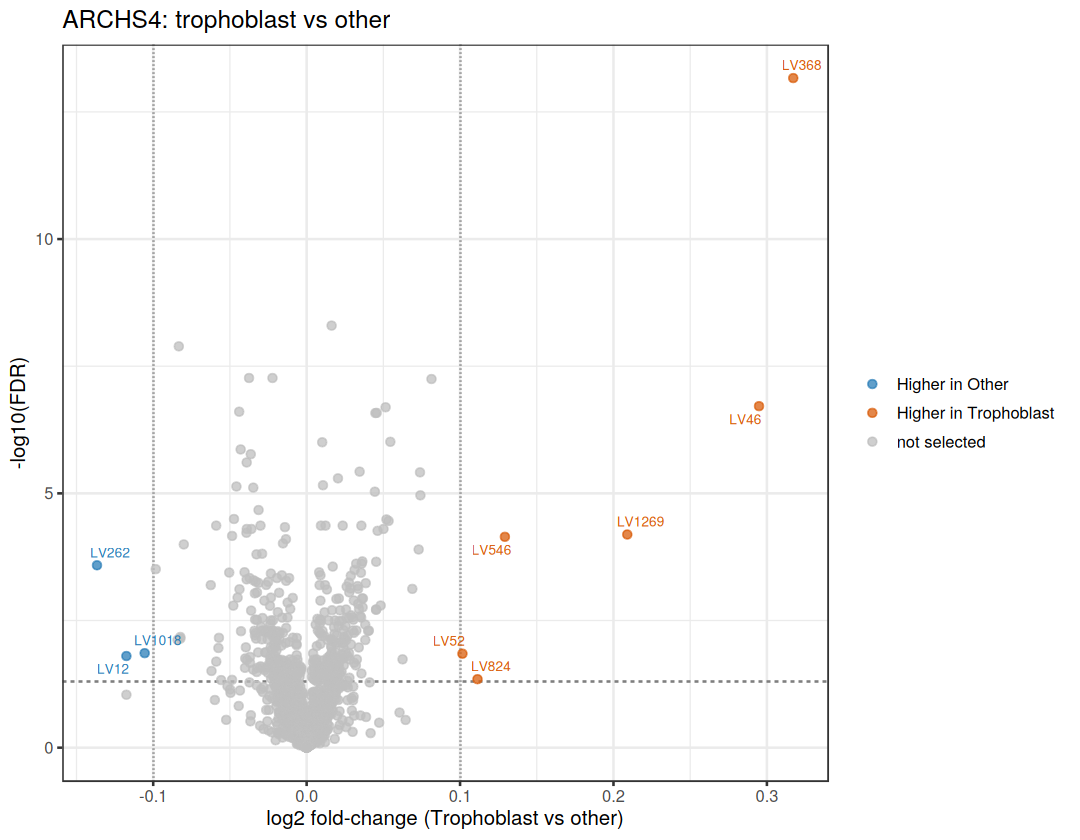

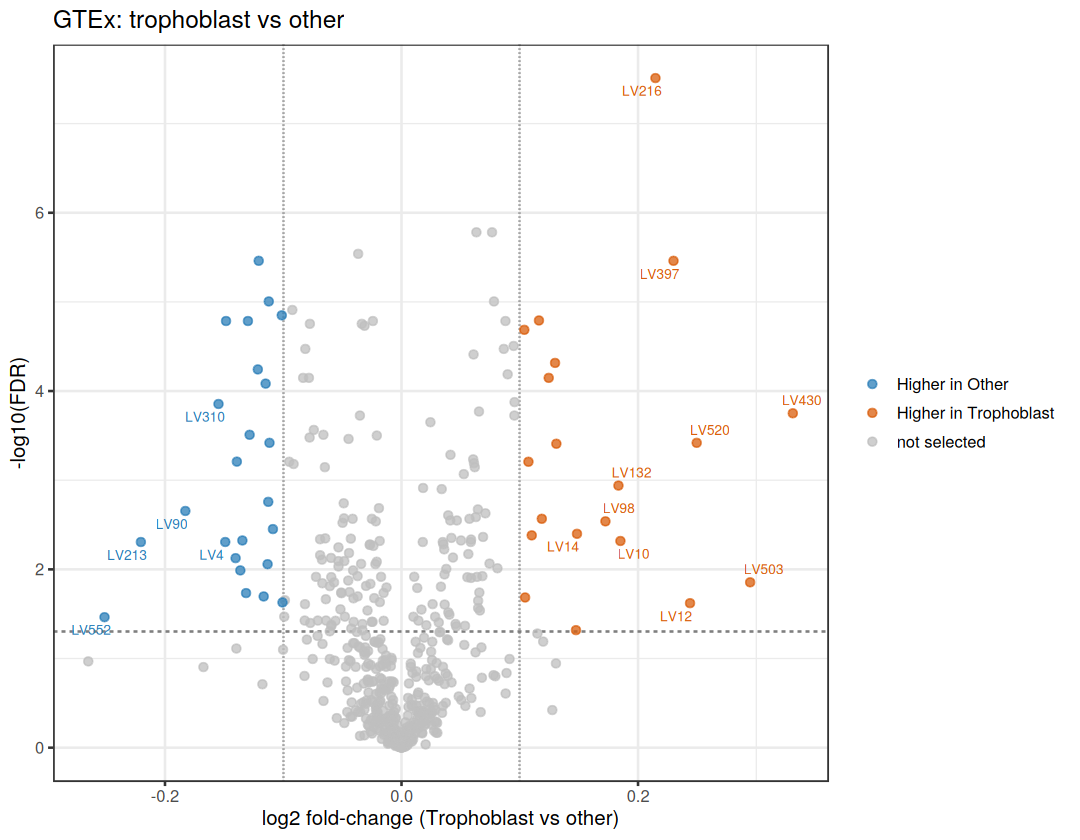

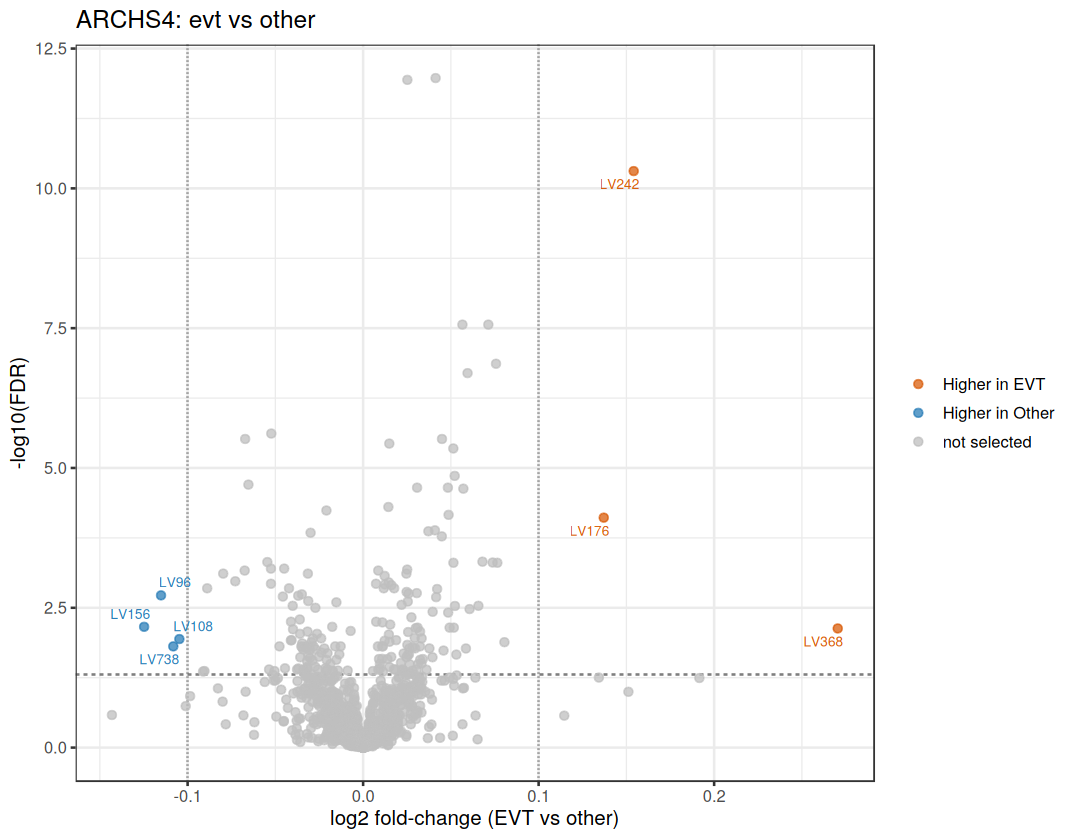

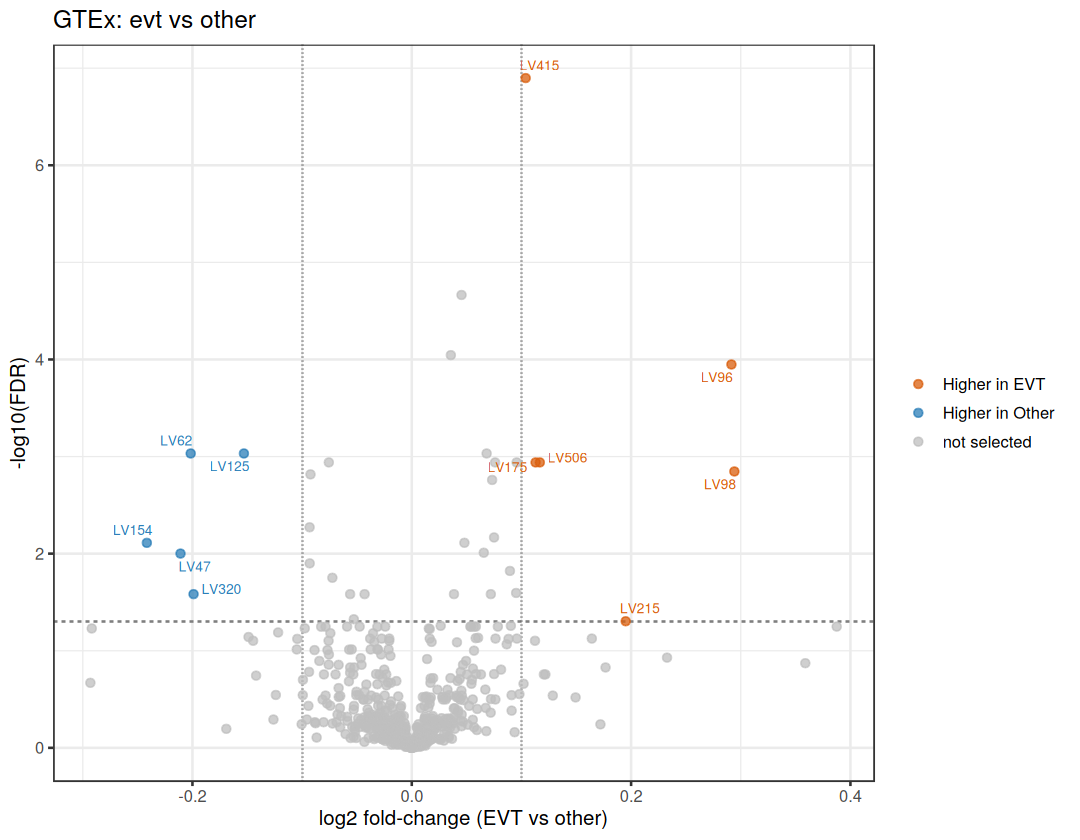

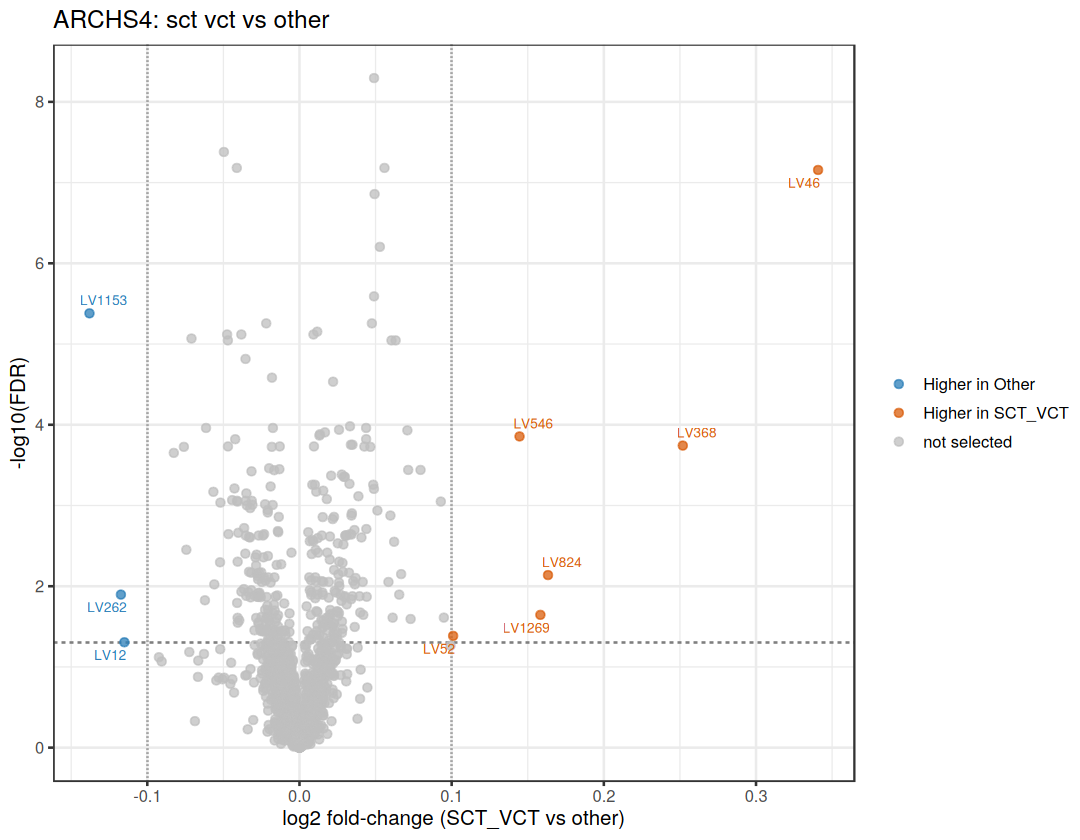

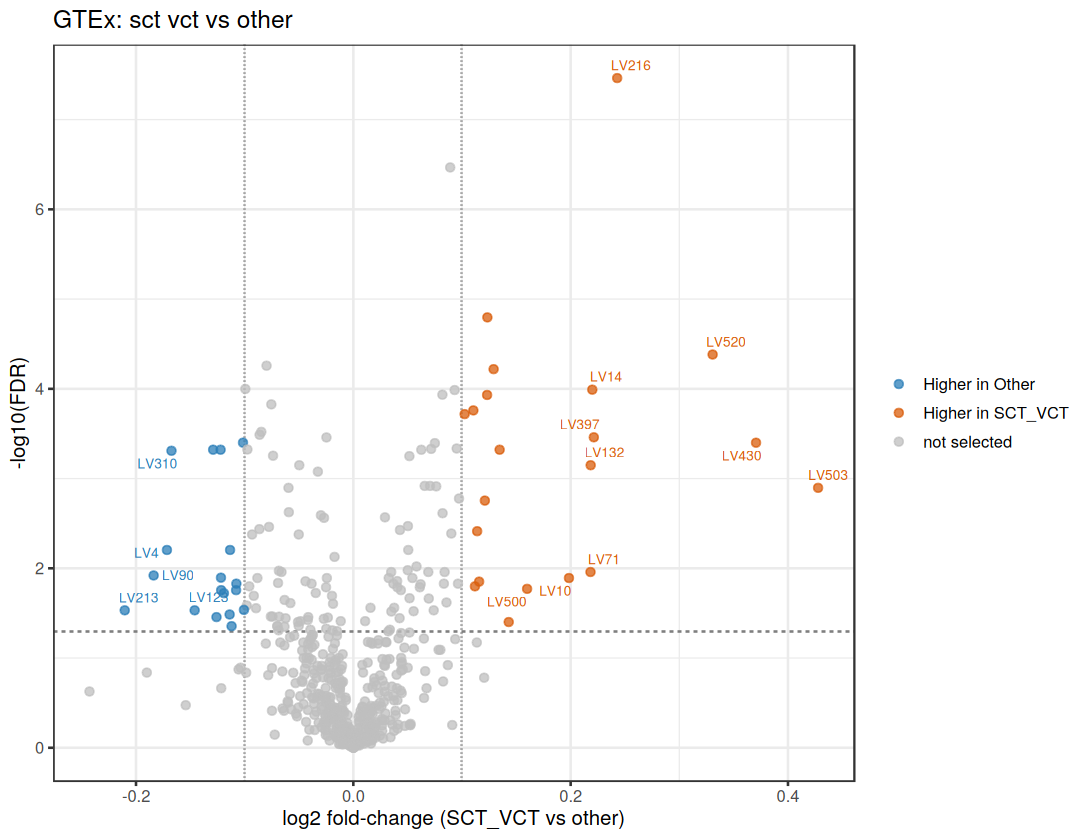

In [14]:
options(repr.plot.width = 9, repr.plot.height = 7)

for (contrast_name in names(ranked_lvs)) {
  for (model_name in names(ranked_lvs[[contrast_name]])) {
    p <- make_volcano(ranked_lvs[[contrast_name]][[model_name]],
                      title = paste0(model_name, ": ", gsub("_", " ", contrast_name)))
    print(p)
    ggsave(file.path(figure_dir, paste0("volcano_", model_name, "_", contrast_name, ".png")),
           plot = p, width = 9, height = 7, dpi = 150)
  }
}

## Target ARCHS4 trophoblast pathway LVs

In [15]:
target_archs4_trophoblast_hits <- dplyr::bind_rows(lapply(names(ranked_lvs), function(contrast_name) {
  archs4_target_annotations <- as.data.frame(models$ARCHS4$summary) %>%
    dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC)) %>%
    dplyr::filter(pathway %in% archs4_trophoblast_pathways) %>%
    dplyr::mutate(
      pathway_clean = clean_pathway(pathway),
      passes_pathway_threshold = FDR < PATHWAY_FDR_CUTOFF & AUC > PATHWAY_AUC_CUTOFF
    )

  archs4_target_annotations %>%
    dplyr::left_join(
      ranked_lvs[[contrast_name]]$ARCHS4 %>%
        dplyr::select(LV, contrast, target_label, logFC, AveExpr, t, P.Value,
                      adj.P.Val, B, abs_logFC, direction,
                      model_pathways = pathways, top_AUC, n_paths),
      by = "LV"
    ) %>%
    dplyr::mutate(
      model = "ARCHS4",
      selected_projected_lv = adj.P.Val < LV_FDR_CUTOFF & abs_logFC >= LV_LOGFC_CUTOFF,
      expected_target_enriched = logFC > 0
    )
})) %>%
  dplyr::arrange(contrast, !expected_target_enriched, adj.P.Val, dplyr::desc(AUC))

write.csv(target_archs4_trophoblast_hits,
          file.path(results_dir, "ARCHS4_target_trophoblast_pathway_LV_hits.csv"),
          row.names = FALSE)
write.csv(gtex_exact_target_check,
          file.path(results_dir, "GTEx_exact_target_trophoblast_pathway_check.csv"),
          row.names = FALSE)

cat("ARCHS4 target LV rows:", nrow(target_archs4_trophoblast_hits), "
")
cat("GTEx exact target LV rows:", nrow(gtex_exact_target_check), "
")

target_archs4_trophoblast_hits %>%
  dplyr::select(contrast, model, LV, pathway, AUC, FDR, logFC, adj.P.Val,
                direction, selected_projected_lv, expected_target_enriched) %>%
  dplyr::group_by(contrast) %>%
  dplyr::slice_head(n = 12)

ARCHS4 target LV rows: 42 


GTEx exact target LV rows: 0 


contrast,model,LV,pathway,AUC,FDR,logFC,adj.P.Val,direction,selected_projected_lv,expected_target_enriched
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
evt_vs_other,ARCHS4,LV460,C8_DESCARTES_MAIN_FETAL_EXTRAVILLOUS_TROPHOBLASTS,0.8435260,1.155100e-06,0.041297637,1.065235e-12,Higher in EVT,FALSE,TRUE
evt_vs_other,ARCHS4,LV774,C8_DESCARTES_MAIN_FETAL_EXTRAVILLOUS_TROPHOBLASTS,0.8035729,2.098556e-05,0.025206308,1.145868e-12,Higher in EVT,FALSE,TRUE
evt_vs_other,ARCHS4,LV242,C8_DESCARTES_MAIN_FETAL_EXTRAVILLOUS_TROPHOBLASTS,0.5370891,5.609024e-01,0.154168216,4.906187e-11,Higher in EVT,TRUE,TRUE
evt_vs_other,ARCHS4,LV46,C8_DESCARTES_FETAL_PLACENTA_TROPHOBLAST_GIANT_CELLS,0.9982730,2.094239e-06,0.065217526,7.115440e-01,Higher in EVT,FALSE,TRUE
evt_vs_other,ARCHS4,LV46,C8_DESCARTES_MAIN_FETAL_TROPHOBLAST_GIANT_CELLS,0.9208964,7.132679e-12,0.065217526,7.115440e-01,Higher in EVT,FALSE,TRUE
evt_vs_other,ARCHS4,LV46,C8_DESCARTES_FETAL_PLACENTA_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS,0.8874958,5.019596e-05,0.065217526,7.115440e-01,Higher in EVT,FALSE,TRUE
evt_vs_other,ARCHS4,LV46,C8_DESCARTES_MAIN_FETAL_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS,0.8507923,4.635207e-07,0.065217526,7.115440e-01,Higher in EVT,FALSE,TRUE
evt_vs_other,ARCHS4,LV46,C8_DESCARTES_MAIN_FETAL_EXTRAVILLOUS_TROPHOBLASTS,0.8133890,8.929868e-06,0.065217526,7.115440e-01,Higher in EVT,FALSE,TRUE
evt_vs_other,ARCHS4,LV442,C8_DESCARTES_FETAL_PLACENTA_SYNCYTIOTROPHOBLASTS_AND_VILLOUS_CYTOTROPHOBLASTS,0.7120039,4.712080e-02,-0.017603622,6.916005e-03,Higher in Other,FALSE,FALSE


## Top ARCHS4 trophoblast LV across cell types

,pathway,LV,AUC,p_value,FDR,npos,nneg,pathway_clean,passes_pathway_threshold,contrast,⋯,adj.P.Val,B,abs_logFC,direction,model_pathways,top_AUC,n_paths,model,selected_projected_lv,expected_target_enriched
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<lgl>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<chr>,<lgl>,<lgl>
1,C8_DESCARTES_FETAL_PLACENTA_TROPHOBLAST_GIANT_CELLS,LV46,0.998273,9.913317e-08,2.094239e-06,8,17950,DESCARTES FETAL PLACENTA TROPHOBLAST GIANT CELLS,TRUE,trophoblast_vs_other,⋯,1.92789e-07,11.61771,0.2948708,Higher in Trophoblast,DESCARTES FETAL PLACENTA TROPHOBLAST GIANT CELLS | DESCARTES FETAL ADRENAL CSH1 CSH2 POSITIVE CELLS | DESCARTES MAIN FETAL TROPHOBLAST GIANT CELLS | DESCARTES FETAL PLACENTA SYNCYTIOTROPHOBLASTS AND VILLOUS CYTOTROPHOBLASTS | DESCARTES MAIN FETAL SYNCYTIOTROPHOBLASTS AND VILLOUS CYTOTROPHOBLASTS | DESCARTES MAIN FETAL EXTRAVILLOUS TROPHOBLASTS,0.998273,6,ARCHS4,TRUE,TRUE


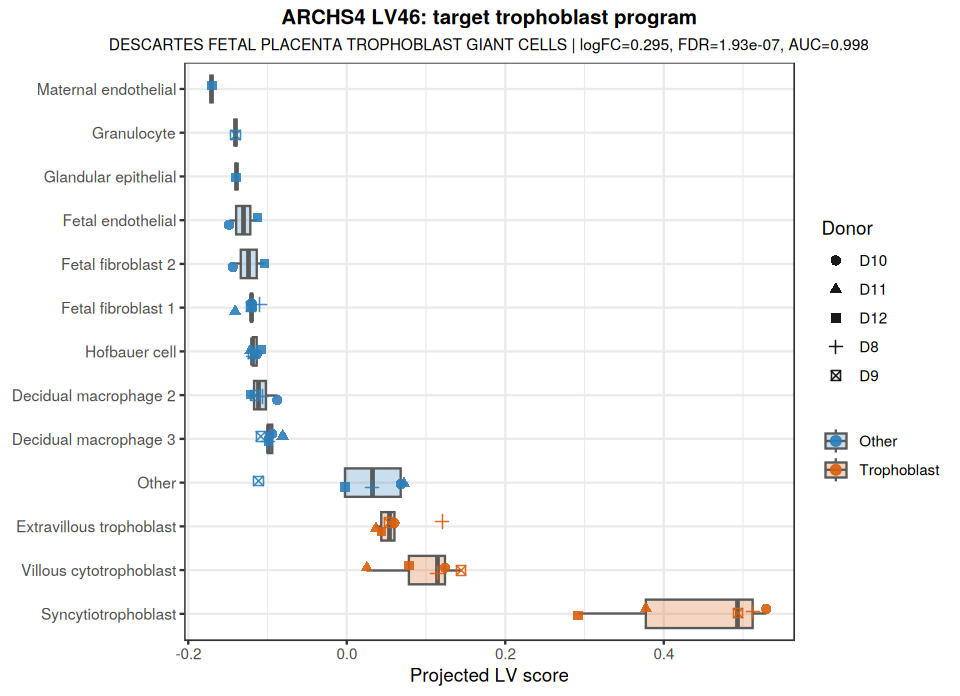

In [16]:
choose_top_archs4_trophoblast_lv <- function(target_tbl, contrast_name = "trophoblast_vs_other") {
  preferred <- target_tbl %>%
    dplyr::filter(contrast == contrast_name,
                  expected_target_enriched,
                  passes_pathway_threshold) %>%
    dplyr::arrange(adj.P.Val, !selected_projected_lv, dplyr::desc(AUC), dplyr::desc(logFC))
  if (nrow(preferred) > 0) return(preferred[1, , drop = FALSE])

  fallback <- target_tbl %>%
    dplyr::filter(contrast == contrast_name) %>%
    dplyr::arrange(adj.P.Val, dplyr::desc(AUC), dplyr::desc(logFC))
  if (nrow(fallback) == 0) return(data.frame())
  fallback[1, , drop = FALSE]
}

top_archs4_trophoblast <- choose_top_archs4_trophoblast_lv(target_archs4_trophoblast_hits)

top_archs4_lv <- if (nrow(top_archs4_trophoblast) == 0) NA_character_ else top_archs4_trophoblast$LV[1]
top_archs4_label <- if (nrow(top_archs4_trophoblast) == 0) {
  "No ARCHS4 target trophoblast LV found"
} else {
  paste0(top_archs4_trophoblast$pathway_clean[1],
         " | logFC=", signif(top_archs4_trophoblast$logFC[1], 3),
         ", FDR=", signif(top_archs4_trophoblast$adj.P.Val[1], 3),
         ", AUC=", signif(top_archs4_trophoblast$AUC[1], 3))
}

options(repr.plot.width = 8, repr.plot.height = 5.8)
p_archs4_trophoblast <- make_lv_score_plot(
  B = B_list$ARCHS4,
  meta = meta_pb,
  lv = top_archs4_lv,
  model_name = "ARCHS4",
  lv_label = top_archs4_label,
  title = paste0("ARCHS4 ", top_archs4_lv, ": target trophoblast program")
)
print(p_archs4_trophoblast)
ggsave(file.path(figure_dir, "top_ARCHS4_trophoblast_LV_scores_by_cell_type.png"),
       plot = p_archs4_trophoblast, width = 8, height = 5.8, dpi = 150)

top_archs4_trophoblast

## Matched GTEx broad placental/developmental LV candidate

LV,pathway,relevance_group,AUC,FDR,logFC,adj.P.Val,direction,selected_projected_lv,expected_target_enriched
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
LV216,C8_DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_RESPIRATORY_HORIZONTAL_BASAL_CELLS,epithelial annotation,0.9055929,1.333291e-03,0.21472855,3.086656e-08,Higher in Trophoblast,TRUE,TRUE
LV216,C8_DESCARTES_FETAL_STOMACH_SQUAMOUS_EPITHELIAL_CELLS,epithelial annotation,0.8078504,9.318751e-04,0.21472855,3.086656e-08,Higher in Trophoblast,TRUE,TRUE
LV216,C8_DESCARTES_MAIN_FETAL_SQUAMOUS_EPITHELIAL_CELLS,epithelial annotation,0.7416054,6.102631e-04,0.21472855,3.086656e-08,Higher in Trophoblast,TRUE,TRUE
LV216,C8_DESCARTES_MAIN_FETAL_URETERIC_BUD_CELLS,developmental/fetal annotation,0.9871231,1.684554e-03,0.21472855,3.086656e-08,Higher in Trophoblast,TRUE,TRUE
LV216,C8_DESCARTES_FETAL_KIDNEY_URETERIC_BUD_CELLS,developmental/fetal annotation,0.8683058,5.152000e-17,0.21472855,3.086656e-08,Higher in Trophoblast,TRUE,TRUE
LV397,C8_DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_RESPIRATORY_HORIZONTAL_BASAL_CELLS,epithelial annotation,0.8589552,4.124375e-03,0.22999139,3.459747e-06,Higher in Trophoblast,TRUE,TRUE
LV397,C8_DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_RESPIRATORY_COLUMNAR_CELLS,epithelial annotation,0.8463343,1.303692e-02,0.22999139,3.459747e-06,Higher in Trophoblast,TRUE,TRUE
LV397,C8_DESCARTES_FETAL_STOMACH_SQUAMOUS_EPITHELIAL_CELLS,epithelial annotation,0.7893259,1.537218e-03,0.22999139,3.459747e-06,Higher in Trophoblast,TRUE,TRUE
LV31,REACTOME_REACTOME_DEVELOPMENTAL_LINEAGE_OF_MAMMARY_GLAND_LUMINAL_EPITHELIAL_CELLS,epithelial annotation,0.9893634,1.682670e-03,0.12983653,4.834634e-05,Higher in Trophoblast,TRUE,TRUE


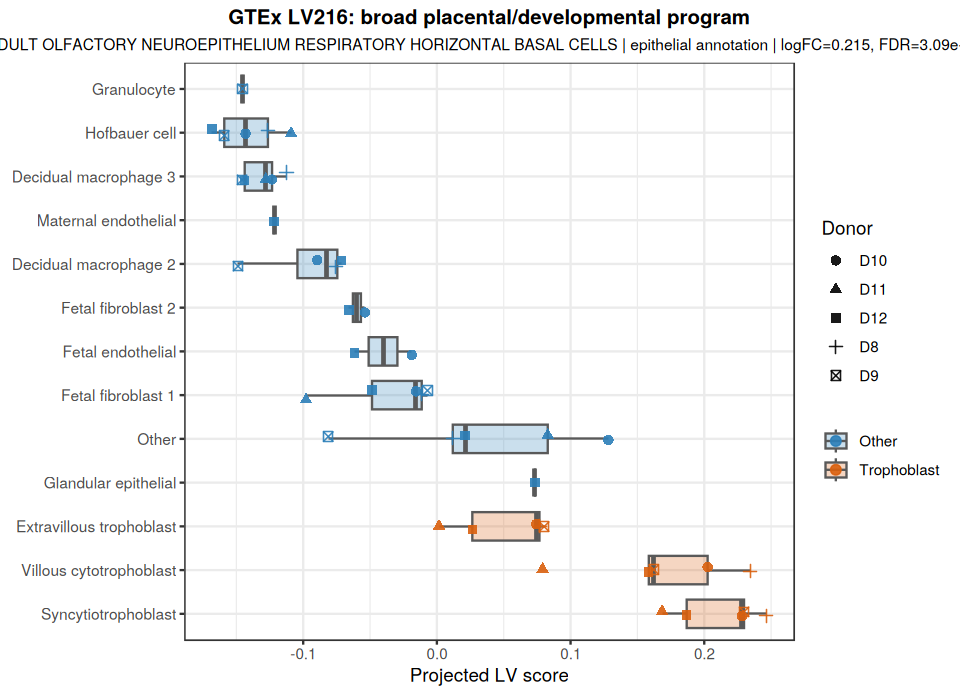

In [17]:
gtex_relevant_annotations <- as.data.frame(models$GTEx$summary) %>%
  dplyr::mutate(FDR = as.numeric(FDR), AUC = as.numeric(AUC),
                pathway_clean = clean_pathway(pathway)) %>%
  dplyr::filter(FDR < PATHWAY_FDR_CUTOFF, AUC > PATHWAY_AUC_CUTOFF) %>%
  dplyr::filter(grepl(broad_gtex_pattern, pathway, ignore.case = TRUE) |
                  grepl(broad_gtex_pattern, pathway_clean, ignore.case = TRUE))

gtex_relevant_lvs <- ranked_lvs$trophoblast_vs_other$GTEx %>%
  dplyr::inner_join(gtex_relevant_annotations, by = "LV", suffix = c("_projection", "_pathway")) %>%
  dplyr::mutate(
    selected_projected_lv = adj.P.Val < LV_FDR_CUTOFF & abs_logFC >= LV_LOGFC_CUTOFF,
    expected_target_enriched = logFC > 0,
    relevance_group = dplyr::case_when(
      grepl("TROPHOBLAST|VILLOUS|CYTOTROPH|SYNCYTIO|EXTRAVILLOUS", pathway, ignore.case = TRUE) ~ "trophoblast-like annotation",
      grepl("PLACENTA|DECIDUA", pathway, ignore.case = TRUE) ~ "placental/decidual annotation",
      grepl("EPITHEL", pathway, ignore.case = TRUE) ~ "epithelial annotation",
      grepl("STROM|FIBROBLAST|MESENCHYM", pathway, ignore.case = TRUE) ~ "stromal/mesenchymal annotation",
      grepl("DEVELOP|EMBRYO|FETAL", pathway, ignore.case = TRUE) ~ "developmental/fetal annotation",
      TRUE ~ "other broad annotation"
    ),
    relevance_rank = dplyr::case_when(
      relevance_group == "trophoblast-like annotation" ~ 1L,
      relevance_group == "placental/decidual annotation" ~ 2L,
      relevance_group == "epithelial annotation" ~ 3L,
      relevance_group == "stromal/mesenchymal annotation" ~ 4L,
      relevance_group == "developmental/fetal annotation" ~ 5L,
      TRUE ~ 6L
    )
  ) %>%
  dplyr::arrange(
    !expected_target_enriched,
    !selected_projected_lv,
    adj.P.Val,
    relevance_rank,
    dplyr::desc(AUC),
    dplyr::desc(abs_logFC)
  )

write.csv(gtex_relevant_lvs,
          file.path(results_dir, "GTEx_broad_placental_developmental_LV_candidates.csv"),
          row.names = FALSE)

top_gtex_relevant <- if (nrow(gtex_relevant_lvs) == 0) data.frame() else gtex_relevant_lvs[1, , drop = FALSE]
top_gtex_lv <- if (nrow(top_gtex_relevant) == 0) NA_character_ else top_gtex_relevant$LV[1]
top_gtex_label <- if (nrow(top_gtex_relevant) == 0) {
  "No significant GTEx broad placental/developmental annotation matched this contrast"
} else {
  paste0(clean_pathway(top_gtex_relevant$pathway[1]),
         " | ", top_gtex_relevant$relevance_group[1],
         " | logFC=", signif(top_gtex_relevant$logFC[1], 3),
         ", FDR=", signif(top_gtex_relevant$adj.P.Val[1], 3),
         ", AUC=", signif(top_gtex_relevant$AUC[1], 3))
}

options(repr.plot.width = 8, repr.plot.height = 5.8)
p_gtex_relevant <- make_lv_score_plot(
  B = B_list$GTEx,
  meta = meta_pb,
  lv = top_gtex_lv,
  model_name = "GTEx",
  lv_label = top_gtex_label,
  title = paste0("GTEx ", top_gtex_lv, ": broad placental/developmental program")
)
print(p_gtex_relevant)
ggsave(file.path(figure_dir, "top_GTEx_broad_placental_LV_scores_by_cell_type.png"),
       plot = p_gtex_relevant, width = 8, height = 5.8, dpi = 150)

gtex_relevant_lvs %>%
  dplyr::select(LV, pathway, relevance_group, AUC, FDR, logFC, adj.P.Val,
                direction, selected_projected_lv, expected_target_enriched) %>%
  dplyr::slice_head(n = 20)

## Pathways inferred from selected shifted LVs

In [18]:
pathway_hits <- dplyr::bind_rows(lapply(names(ranked_lvs), function(contrast_name) {
  dplyr::bind_rows(lapply(names(models), function(model_name) {
    extract_shifted_pathways(ranked_lvs[[contrast_name]][[model_name]], models[[model_name]], model_name)
  }))
}))

pathway_summary <- if (nrow(pathway_hits) == 0) {
  data.frame()
} else {
  pathway_hits %>%
    dplyr::group_by(contrast, model, pathway_clean, direction) %>%
    dplyr::summarise(
      n_lvs = dplyr::n_distinct(LV),
      best_AUC = max(AUC, na.rm = TRUE),
      min_pathway_FDR = min(FDR, na.rm = TRUE),
      min_lv_FDR = min(adj.P.Val, na.rm = TRUE),
      max_abs_logFC = max(abs_logFC, na.rm = TRUE),
      mean_logFC = mean(logFC, na.rm = TRUE),
      LVs = paste(unique(LV), collapse = ", "),
      .groups = "drop"
    ) %>%
    dplyr::arrange(contrast, model, direction, dplyr::desc(max_abs_logFC), min_lv_FDR)
}

for (model_name in names(models)) {
  write.csv(pathway_hits %>% dplyr::filter(model == model_name),
            file.path(results_dir, paste0(model_name, "_selected_LV_pathway_hits.csv")),
            row.names = FALSE)
  write.csv(pathway_summary %>% dplyr::filter(model == model_name),
            file.path(results_dir, paste0(model_name, "_selected_pathway_summary.csv")),
            row.names = FALSE)
}

cat("Annotated pathway hits:", nrow(pathway_hits), "
")
pathway_summary %>%
  dplyr::group_by(contrast, model, direction) %>%
  dplyr::summarise(n_pathways = dplyr::n_distinct(pathway_clean), .groups = "drop")

Annotated pathway hits: 283 


contrast,model,direction,n_pathways
<chr>,<chr>,<chr>,<int>
evt_vs_other,ARCHS4,Higher in EVT,2
evt_vs_other,ARCHS4,Higher in Other,2
evt_vs_other,GTEx,Higher in EVT,12
evt_vs_other,GTEx,Higher in Other,2
sct_vct_vs_other,ARCHS4,Higher in Other,18
sct_vct_vs_other,ARCHS4,Higher in SCT_VCT,26
sct_vct_vs_other,GTEx,Higher in Other,21
sct_vct_vs_other,GTEx,Higher in SCT_VCT,52
trophoblast_vs_other,ARCHS4,Higher in Other,20


## Interpretation and final conclusion

In [19]:
archs4_directional_support <- nrow(top_archs4_trophoblast) > 0 &&
  isTRUE(top_archs4_trophoblast$expected_target_enriched[1]) &&
  isTRUE(top_archs4_trophoblast$adj.P.Val[1] < LV_FDR_CUTOFF)

archs4_selected_support <- archs4_directional_support &&
  isTRUE(top_archs4_trophoblast$abs_logFC[1] >= LV_LOGFC_CUTOFF)

gtex_exact_targets_present <- nrow(gtex_exact_target_check) > 0

archs4_effect_note <- if (nrow(top_archs4_trophoblast) == 0) {
  ""
} else if (archs4_selected_support) {
  " This passes both the LV FDR and absolute logFC filters."
} else if (archs4_directional_support) {
  paste0(" Significant and directionally correct, but below the absolute logFC filter of ",
         LV_LOGFC_CUTOFF, ".")
} else {
  " Does not pass the directional FDR support check."
}

archs4_text <- if (nrow(top_archs4_trophoblast) == 0) {
  "No ARCHS4 LV annotated with the target trophoblast pathways was found."
} else {
  paste0(
    "The strongest ARCHS4 trophoblast LV is ", top_archs4_trophoblast$LV[1],
    ", annotated to ", top_archs4_trophoblast$pathway_clean[1],
    ". In the trophoblast-vs-other contrast: logFC=",
    signif(top_archs4_trophoblast$logFC[1], 3),
    ", FDR=", signif(top_archs4_trophoblast$adj.P.Val[1], 3), ".",
    archs4_effect_note
  )
}

gtex_candidate_text <- if (nrow(top_gtex_relevant) == 0) {
  "No GTEx LV with a significant broad placental or developmental annotation was found."
} else {
  paste0(
    "Best GTEx candidate: ", top_gtex_relevant$LV[1],
    ", annotated to ", clean_pathway(top_gtex_relevant$pathway[1]),
    " (", top_gtex_relevant$relevance_group[1], "). logFC=",
    signif(top_gtex_relevant$logFC[1], 3),
    ", FDR=", signif(top_gtex_relevant$adj.P.Val[1], 3), "."
  )
}

format_metric <- function(x) {
  if (length(x) == 0 || is.na(x)) return("NA")
  sprintf("%.3f", x)
}

ari_best_celltype <- ari_summary %>%
  dplyr::arrange(dplyr::desc(mean_ari)) %>%
  dplyr::slice_head(n = 1)

ari_overall_text <- if (nrow(ari_best_celltype) == 0 || is.na(ari_best_celltype$mean_ari[1])) {
  "The ARI analysis could not assign a reliable winner for the annotated cell-type labels."
} else {
  paste0(
    "For annotated cell-type labels, mean ARI was higher for ",
    ari_best_celltype$model[1], " (",
    format_metric(ari_best_celltype$mean_ari[1]), ")."
  )
}

specificity_sentence <- if (archs4_directional_support && !gtex_exact_targets_present) {
  paste0("The exact trophoblast annotations are present in the ARCHS4 model summary, ",
         "absent from the GTEx summary by exact pathway name, ",
         "and the top ARCHS4 trophoblast LV is significantly enriched in trophoblast pseudobulks.")
} else if (!gtex_exact_targets_present) {
  paste0("The exact target annotations remain ARCHS4-specific by pathway name, ",
         "but the top ARCHS4 target LV did not meet the directional FDR support criterion in this run.")
} else {
  paste0("Both models contain exact target annotations; this run is best read as a ",
         "projection-strength comparison.")
}

conclusion <- c(
  "Conclusion", "",
  paste0("E-MTAB-6701 placenta pseudobulks were projected into ARCHS4 and GTEx CLAMP Hallmark models. ",
         "Trophoblast cells vs other placental cell types were contrasted, plus EVT-vs-other and SCT/VCT-vs-other."),
  "",
  archs4_text,
  paste0("GTEx exact target annotations present: ", gtex_exact_targets_present, ". ", gtex_candidate_text),
  "",
  paste0(ari_overall_text, " The ARI result reflects global projection geometry across all cell types, ",
         "while LV contrasts and pathway annotations provide the targeted trophoblast-program evidence."),
  "",
  paste0(specificity_sentence, " ARCHS4 captures trophoblast-specific placental cell-state programs ",
         "more directly through explicit trophoblast annotations; GTEx captures related but broader programs.")
)

writeLines(conclusion)
writeLines(conclusion, file.path(results_dir, "final_conclusion.txt"))

Conclusion

This analysis pseudobulked E-MTAB-6701 placenta single-cell profiles by donor and annotated cell type, then projected each pseudobulk sample into the ARCHS4 and GTEx CLAMP models. The primary biological test was trophoblast cells versus other placental cell types, with additional EVT-vs-other and SCT/VCT-vs-other contrasts to check finer trophoblast states.

The strongest direct ARCHS4 trophoblast result comes from LV46, annotated to DESCARTES FETAL PLACENTA TROPHOBLAST GIANT CELLS. In the trophoblast-vs-other contrast this LV has logFC=0.295 and FDR=1.93e-07. This passes both the LV FDR and absolute logFC filters.
GTEx exact target trophoblast annotations present: FALSE. The best matched GTEx candidate was LV216, annotated to DURANTE ADULT OLFACTORY NEUROEPITHELIUM RESPIRATORY HORIZONTAL BASAL CELLS (epithelial annotation). In the same trophoblast-vs-other contrast it has logFC=0.215 and FDR=3.09e-08.

The GTEx comparison should be interpreted as a specificity comparison, 

## Export panel figure for fig4

In [ ]:
suppressPackageStartupMessages({
  library(scales)
  library(cowplot)
})

PANEL_DIR <- here("output", "99_panels", "fig4")
dir.create(PANEL_DIR, recursive = TRUE, showWarnings = FALSE)

ct_abbrev <- c(
  "Extravillous trophoblast" = "EVT",
  "Syncytiotrophoblast"      = "SCT",
  "Villous cytotrophoblast"  = "VCT",
  "Hofbauer cell"            = "Hofbauer",
  "Fetal fibroblast 1"       = "Fibro. 1",
  "Fetal fibroblast 2"       = "Fibro. 2",
  "Fetal endothelial"        = "Fetal endo.",
  "Maternal endothelial"     = "Mat. endo.",
  "Decidual macrophage 2"    = "Dec. mac. 2",
  "Decidual macrophage 3"    = "Dec. mac. 3",
  "Glandular epithelial"     = "Gland. epi.",
  "Granulocyte"              = "Granulocyte",
  "Other"                    = "Other"
)

TROPH_COLORS <- c(Trophoblast = "#D55E00", Other = "#BBBBBB")
donor_shapes <- c(D8 = 15, D9 = 16, D10 = 17, D11 = 18, D12 = 19)

tight_limits_local <- function(x, pad_frac = 0.04, min_span = 0.2) {
  v <- x[is.finite(x)]
  if (!length(v)) return(c(0, 1))
  r <- range(v); s <- diff(r)
  if (s < min_span) { mid <- mean(r); r <- c(mid - min_span/2, mid + min_span/2); s <- diff(r) }
  r + c(-1, 1) * max(s * pad_frac, 1e-6)
}
tight_breaks_local <- function(lims, n = 3) {
  b <- pretty(lims, n = n); b[b >= lims[1] & b <= lims[2]]
}

theme_panel <- function() {
  theme_classic(base_size = 7, base_family = "Helvetica") +
  theme(
    plot.title   = element_text(size = 5.0, hjust = 0.5, margin = margin(b = 1)),
    axis.text    = element_text(size = 5.0),
    axis.title   = element_text(size = 6.5),
    axis.text.y  = element_text(size = 4.0, lineheight = 0.82),
    axis.line    = element_line(linewidth = 0.35),
    axis.ticks   = element_line(linewidth = 0.35),
    panel.grid   = element_blank(),
    plot.margin  = unit(c(2, 2, 2, 1), "mm")
  )
}

make_score_df <- function(proj_mat, lv, meta) {
  df <- data.frame(sample = colnames(proj_mat),
                   score  = as.numeric(proj_mat[lv, ]),
                   stringsAsFactors = FALSE) %>%
    dplyr::left_join(meta, by = "sample") %>%
    dplyr::mutate(ct_label = dplyr::recode(cell_type, !!!ct_abbrev))
  ct_ord <- df %>%
    dplyr::group_by(ct_label) %>%
    dplyr::summarise(med = median(score, na.rm = TRUE), .groups = "drop") %>%
    dplyr::arrange(med) %>% dplyr::pull(ct_label)
  df$ct_label <- factor(df$ct_label, levels = ct_ord)
  df
}

proj_a <- B_list$ARCHS4
proj_g <- B_list$GTEx

df_a <- make_score_df(proj_a, "LV46",  meta_pb)
df_g <- make_score_df(proj_g, "LV216", meta_pb)

make_score_panel <- function(df, title) {
  xl <- tight_limits_local(df$score)
  ggplot(df, aes(y = ct_label, x = score)) +
    geom_vline(xintercept = 0, colour = "grey75", linewidth = 0.28, linetype = "dashed") +
    geom_boxplot(aes(fill = condition_trophoblast), outlier.shape = NA,
                 alpha = 0.30, colour = "grey40", width = 0.62, linewidth = 0.28) +
    geom_jitter(aes(colour = condition_trophoblast, shape = donor),
                height = 0.13, width = 0, size = 1.05, alpha = 0.85) +
    scale_fill_manual(values   = TROPH_COLORS, guide = "none") +
    scale_colour_manual(values = TROPH_COLORS, guide = "none") +
    scale_shape_manual(values  = donor_shapes,  guide = "none") +
    scale_x_continuous(limits  = xl,
                       breaks  = tight_breaks_local(xl, 3),
                       labels  = scales::label_number(accuracy = 0.1, trim = TRUE),
                       expand  = expansion(mult = c(0.02, 0.04))) +
    labs(title = title, y = NULL, x = "Projected LV score") +
    theme_panel()
}

p_a <- make_score_panel(df_a, "ARCHS4 LV46 \u2013 Trophoblast giant cells (AUC = 1.00)")
p_g <- make_score_panel(df_g, "GTEx LV216 \u2013 Squamous epithelial cells (AUC = 0.93)")

legend_df <- data.frame(
  label  = c("Trophoblast", "Other"),
  x = c(1, 2), y = 1,
  colour = c("#D55E00", "#BBBBBB")
)
p_leg <- ggplot(legend_df, aes(x, y, colour = label)) +
  geom_point(size = 1.4, shape = 16) +
  geom_text(aes(label = label), hjust = -0.12,
            size = 3.5 / .pt, family = "Helvetica") +
  scale_colour_manual(values = setNames(legend_df$colour, legend_df$label),
                      guide = "none") +
  xlim(0.7, 3.2) + ylim(0.7, 1.3) +
  theme_void(base_family = "Helvetica") +
  theme(plot.margin = margin(0, 0, 0, 0))

panel_G <- cowplot::plot_grid(
  cowplot::plot_grid(ggplot2::ggdraw(), p_leg, ncol = 2, rel_widths = c(0.05, 0.95)),
  p_a, p_g,
  ncol = 1, rel_heights = c(0.07, 1, 1)
)

options(repr.plot.width = 6, repr.plot.height = 7)
print(panel_G)

ggplot2::ggsave(
  file.path(PANEL_DIR, "placenta_trophoblast_panel_G.pdf"),
  panel_G, width = 60, height = 80, units = "mm",
  device = grDevices::cairo_pdf, bg = "white"
)
ggplot2::ggsave(
  file.path(PANEL_DIR, "placenta_trophoblast_panel_G.png"),
  panel_G, width = 60, height = 80, units = "mm", dpi = 300, bg = "white"
)
cat("Panel G saved to", PANEL_DIR, "\n")